# Time Evolution of a Burning/Cooling Front

We construct a static random velocity field and advect a reacting scalar $\theta$ through it using an explicit RK3 method. We then examine the time evolution in three regimes: diffusive, passive-scalar/turbulent, and cooling/burning.

Our system is represented by the equation

$$ \partial_t \theta + \mathbf{u} \cdot \nabla \theta - \chi \Delta \theta = S, \qquad \text{where $S$ is the source term}. $$

The sign of $S$ determines whether the front is burning or cooling.

In [11]:
# %pip install scipy scikit-image numba
%matplotlib inline
import os
from time import perf_counter

import numpy as np
import matplotlib.pyplot as plt
from numba import njit, set_num_threads
from scipy import fft as sfft
plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (7, 4.2)

# Domain and numerical grid
NT = 256
ASPECT = 2
Ly = 1.0
Lx = ASPECT * Ly
nx, ny = ASPECT * NT, NT
dx = Lx / nx

# User-specified turbulent length scales
L_outer = Ly
ell_min = 8 * dx

# The FFT uses angular wavenumber, so k = 2*pi/ell.
kmin = 2 * np.pi / L_outer
kmax = 2 * np.pi / ell_min

print(f"grid {nx} x {ny} (aspect {ASPECT}:1), dx={dx:.6f}")
print(
    f"L_outer={L_outer:.6f}, ell_min={ell_min:.6f}, "
    f"kmin={kmin:.6f}, kmax={kmax:.6f}"
)

grid 512 x 256 (aspect 2:1), dx=0.003906
L_outer=1.000000, ell_min=0.031250, kmin=6.283185, kmax=201.061930


## Velocity Setup

Our velocity field is a 2D static Gaussian random field built in Fourier space. We do this to simulate turbulence, ensure the field is incompressible, and follow the Kolmogorov energy spectrum for turbulence $(E(k) \propto k^{-5/3})$

We begin by taking the curl of a scalar streamfunction, $\psi$, to get an incompressible velocity field: $u_x = \dfrac{\partial \psi}{\partial y}, \, u_y = -\dfrac{\partial \psi}{\partial x}$.

In Fourier space, $\hat u_x (\vec{k}) = ik_y\hat\psi (\vec{k}), \, \hat u_y (\vec{k}) = -ik_x\hat\psi(\vec{k})$.

We denote the standard Gaussian white noise by $W(\vec{k})$. $\hat W$ is the FT of the white noise.

In Fourier space, the streamfunction is $\hat\psi (\vec{k}) = A(|\vec{k}|) \hat W (\vec{k})$, where $A(k)$ is a radial filter that enforces the desired turbulence/roughness.

$$A(k) = 
 \begin{cases}
    k^{-7/3} \qquad k_\text{min} \leq k \leq k_\text{max} \\
    0 \qquad \text{otherwise}
 \end{cases}$$
The user specifies the retained wavelength range through $L_{\rm outer}$ and $\ell_{\min}$. Because the code uses angular wavenumber, $k=2\pi/\ell$, so

$$
k_{\min}=\frac{2\pi}{L_{\rm outer}},
\qquad
k_{\max}=\frac{2\pi}{\ell_{\min}}.
$$

To obtain the velocity field in the Cartesian grid, we pass $\hat u_x$ and $\hat u_y$ through an inverse FFT.

$$u_x(x,y) = \mathcal{F}^{-1} [ik_y\hat\psi (\vec{k})], \qquad u_y(x,y) = 
\mathcal{F}^{-1} [-ik_x\hat\psi(\vec{k})]$$

After transforming back, we subtract the spatial mean of each component and normalize the combined vector RMS:

$$
\langle u_x\rangle = \langle u_y\rangle = 0,
\qquad
U_{\rm rms} \equiv
\sqrt{\left\langle u_x^2 + u_y^2\right\rangle} = 1.
$$

The velocity is generated once with `VELOCITY_SEED = 42`, plotted, and then reused directly by the simulation. Before integrating, we verify its mean and recompute $U_{\rm rms}$ from these same arrays. The simulator consistently uses the user-specified outer scale: $\chi = U_{\rm rms}L_{\rm outer}/Pe$ and $S_0 = Da\,U_{\rm rms}/L_{\rm outer}$.


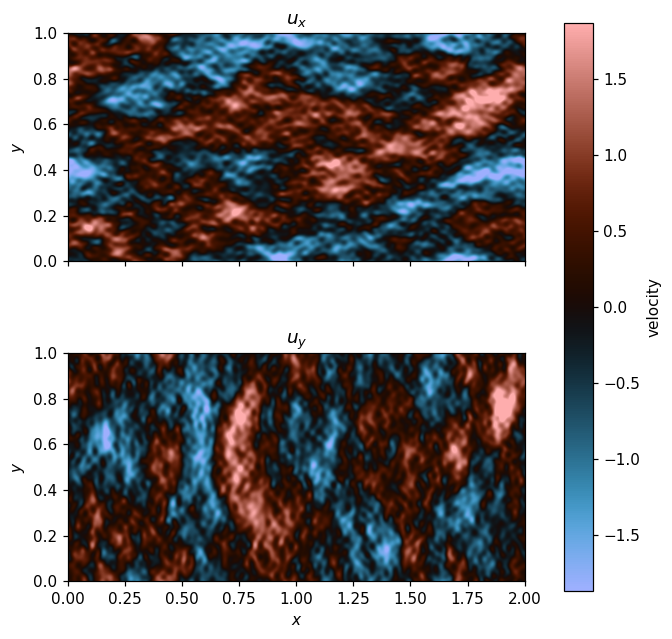

Preview velocity: <ux>=+6.939e-18, <uy>=-4.513e-18, U_rms=1.000000000000


In [24]:
def make_velocity(nx, ny, Lx, Ly, kmin, kmax, seed=None):
    rng = np.random.default_rng(seed)

    kx = 2 * np.pi * np.fft.fftfreq(nx, d=Lx / nx)
    ky = 2 * np.pi * np.fft.fftfreq(ny, d=Ly / ny)
    KX, KY = np.meshgrid(kx, ky)

    K = np.sqrt(KX**2 + KY**2)

    W = rng.standard_normal((ny, nx)) + 1j * rng.standard_normal((ny, nx))

    A = np.zeros_like(K)
    mask = (K >= kmin) & (K <= kmax)
    A[mask] = K[mask]**(-7/3)
    A[K == 0] = 0.0

    psi_hat = A * W

    ux_hat = 1j * KY * psi_hat
    uy_hat = -1j * KX * psi_hat

    ux = np.fft.ifft2(ux_hat).real
    uy = np.fft.ifft2(uy_hat).real

    ux -= np.mean(ux)
    uy -= np.mean(uy)
    velocity_rms = np.sqrt(np.mean(ux**2 + uy**2))
    ux /= velocity_rms
    uy /= velocity_rms

    return ux, uy


VELOCITY_SEED = 42

# L_outer and ell_min are the user choices; kmin and kmax were derived above.
ux, uy = make_velocity(
    nx=nx,
    ny=ny,
    Lx=Lx,
    Ly=Ly,
    kmin=kmin,
    kmax=kmax,
    seed=VELOCITY_SEED,
)

velocity_limit = max(np.percentile(np.abs(ux), 99), np.percentile(np.abs(uy), 99))
fig, axes = plt.subplots(2, 1, figsize=(6,6), sharex=True, sharey=True, constrained_layout=True)

for ax, field, title in zip(axes, (ux, uy), (r"$u_x$", r"$u_y$")):
    image = ax.imshow(
        field,
        extent=(0, Lx, 0, Ly),
        origin="lower",
        cmap="berlin",
        vmin=-velocity_limit,
        vmax=velocity_limit,
    )
    ax.set_title(title)

axes[0].set_ylabel("$y$")
axes[1].set_ylabel("$y$")
axes[1].set_xlabel("$x$")

fig.colorbar(image, ax=axes, label="velocity", shrink=0.9)
plt.show()

preview_rms = np.sqrt(np.mean(ux**2 + uy**2))
print(
    "Preview velocity: "
    f"<ux>={np.mean(ux):+.3e}, "
    f"<uy>={np.mean(uy):+.3e}, "
    f"U_rms={preview_rms:.12f}"
)

## Explicit RK3 Method

We want to advance $\theta$ through time, and we do this via a RK3 scheme. We begin by rewriting the equation as

$$\partial_t \theta = S - \mathbf{u} \cdot \nabla \theta + \chi \Delta \theta$$

Denote the RHS by $R(\theta)$. The RK3 scheme is implemented as follows:

$$
\theta^{(1)}=\theta^n+\Delta t\,R(\theta^n),\quad
\theta^{(2)}=\tfrac34\theta^n+\tfrac14\!\big(\theta^{(1)}+\Delta t\,R(\theta^{(1)})\big),\quad
\theta^{n+1}=\tfrac13\theta^n+\tfrac23\!\big(\theta^{(2)}+\Delta t\,R(\theta^{(2)})\big).
$$

The time-step, $\Delta t$, is limited by the following constraint to ensure the integration does not blow up:

$$
\Delta t = \min \Big(C_a \Big( \dfrac{\Delta x}{\max \mathbf{u}} \Big), C_d \Big( \dfrac{\Delta x ^2}{\chi} \Big), C_s\Big(\dfrac{\theta}{\text{RHS}}\Big) \Big)
$$

## Pseudo-Spectral Method

To advect the scalar field $\theta$, we must evaluate the nonlinear advection term $\mathbf{u} \cdot \nabla \theta$ and the diffusion term $\chi \Delta \theta$.

Finite difference methods evaluate these gradients on the physical grid, which introduces numerical dispersion and smearing. The pseudo-spectral method solves this by calculating all spatial derivatives in Fourier space, where derivatives become exact algebraic multiplications:

$$\partial_x \theta \implies ik_x \hat{\theta}, \qquad \Delta \theta \implies -(k_x^2 + k_y^2)\hat{\theta}$$

While the derivatives are computed in frequency space, we use the Inverse Fast Fourier Transform to bring the exact gradients back to physical space to multiply them by the velocity field. Doing this multiplication in physical space takes $\mathcal{O}(N \log N)$ operations via FFTs, which is much faster than doing the exact spectral convolution in Fourier space $\mathcal{O}(N^2)$.

### Efficient real-valued spectral stages

Because $\theta$ is real, its negative Fourier frequencies duplicate the positive ones. `rfft2` keeps only the nonredundant half-spectrum. Each RK3 stage then reuses the same $\widehat{\theta}$ for the two gradients and Laplacian, whose inverse transforms are batched and threaded. Finally, Numba fuses the pointwise cooling, advection, and diffusion assembly into one parallel pass. The equation and three-stage RK3 update are unchanged; the implementation simply avoids redundant transform and array work.

In [13]:
# pseudo-spectral method
@njit(parallel=True)
def assemble_rhs(theta, ux, uy, dtheta_dx, dtheta_dy, laplacian, chi, S_0):
    reaction = S_0 * 0.5 * (
        np.tanh((theta - 0.5 + 0.2) / 0.04)
        - np.tanh((theta - 0.5 - 0.2) / 0.04)
    )
    return reaction - (ux * dtheta_dx + uy * dtheta_dy) + chi * laplacian


def compute_rhs(theta, ux, uy, KX, KY, K_sq, chi, S_0, dealias_mask):
    theta_hat = sfft.rfft2(theta, workers=FFT_WORKERS)
    theta_hat *= dealias_mask

    spectral_terms = np.empty((3,) + theta_hat.shape, dtype=theta_hat.dtype)

    spectral_terms[0] = theta_hat
    spectral_terms[0] *= KX
    spectral_terms[0] *= 1j

    spectral_terms[1] = theta_hat
    spectral_terms[1] *= KY
    spectral_terms[1] *= 1j

    spectral_terms[2] = theta_hat
    spectral_terms[2] *= -K_sq

    dtheta_dx, dtheta_dy, laplacian = sfft.irfft2(
        spectral_terms,
        s=theta.shape,
        axes=(-2, -1),
        workers=FFT_WORKERS,
    )

    return assemble_rhs(
        theta,
        ux,
        uy,
        dtheta_dx,
        dtheta_dy,
        laplacian,
        chi,
        S_0,
    )

In [14]:
# rk3 setup
def rk3_step(theta, ux, uy, KX, KY, K_sq, chi, S_0, dt, dealias_mask, rhs1=None):
    if rhs1 is None:
        rhs1 = compute_rhs(theta, ux, uy, KX, KY, K_sq, chi, S_0, dealias_mask)
    theta1 = theta + dt * rhs1

    rhs2 = compute_rhs(theta1, ux, uy, KX, KY, K_sq, chi, S_0, dealias_mask)
    theta2 = 0.75 * theta + 0.25 * (theta1 + dt * rhs2)

    rhs3 = compute_rhs(theta2, ux, uy, KX, KY, K_sq, chi, S_0, dealias_mask)
    return (1.0 / 3.0) * theta + (2.0 / 3.0) * (theta2 + dt * rhs3)

def compute_dt(theta, rhs, dx, max_u, chi, C_a=0.5, C_d=0.2, C_s=0.5, floor_frac=1e-2):
    dt_adv = C_a * (dx/max_u) # advective CFL
    dt_dif = C_d * (dx**2 / chi) # diffusive CFL
    left, right = np.abs(theta), np.abs(rhs) # used to compute theta/|RHS| local timescale
    active = (left > floor_frac * left.max()) & (right > 0) # ignore too small vals
    dt_src = C_s * np.min(left[active] / right[active]) if active.any() else np.inf
    return min(dt_adv, dt_dif, dt_src)

In [15]:
# simulator
def simulator(
    Pe,
    Da,
    theta_initial,
    ux,
    uy,
    KX,
    KY,
    K_sq,
    U_rms,
    max_u,
    dx,
    L_outer,
    save_times,
    dealias_mask,
    C_a=0.5,
    C_d=0.2,
    C_s=0.5,
):
    chi = (U_rms * L_outer) / Pe
    S_0 = (Da * U_rms) / L_outer

    # Each regime evolves its own copy of the common initial condition.
    theta = theta_initial.copy()

    st = sorted(save_times)
    snap = {"chi": chi, "S_0": S_0, "n_steps": 0}
    t, idx = 0.0, 0
    if st[0] <= 0.0:
        snap[st[0]] = theta.copy()
        idx = 1

    while idx < len(st):
        rhs = compute_rhs(
            theta, ux, uy, KX, KY, K_sq, chi, S_0, dealias_mask
        )
        dt = min(
            compute_dt(theta, rhs, dx, max_u, chi, C_a, C_d, C_s),
            st[idx] - t,
        )
        theta = rk3_step(
            theta,
            ux,
            uy,
            KX,
            KY,
            K_sq,
            chi,
            S_0,
            dt,
            dealias_mask,
            rhs1=rhs,
        )
        theta = np.clip(theta, 0.0, 1.0)
        t += dt
        snap["n_steps"] += 1

        if t >= st[idx] - 1e-12:
            snap[st[idx]] = theta.copy()
            t = st[idx]
            idx += 1

    return snap

### Choosing the FFT worker count

FFT threading depends on the grid and the machine. The next cell briefly times the same transform pattern used by one RHS evaluation—one `rfft2` followed by one batched `irfft2`—for 1, 2, 4, and 8 workers. It keeps the fastest count for the simulation and runs this benchmark only once.

In [16]:
# FFT worker setup
# FFT threading performance depends on both the machine and the grid size.
# Test only a few modest worker counts that this machine can support.
worker_candidates = [
    workers
    for workers in (1, 2, 4, 8)
    if workers <= (os.cpu_count() or 1)
]

# These temporary arrays have the same shapes and dtypes used by compute_rhs:
# one real field for rfft2 and a three-field batch for irfft2.
_fft_probe = np.zeros((ny, nx), dtype=np.float64)
_fft_probe_hat = sfft.rfft2(_fft_probe)
_fft_probe_batch = np.zeros(
    (3,) + _fft_probe_hat.shape,
    dtype=np.complex128,
)
worker_times = {}

for workers in worker_candidates:
    # Warm up the FFT implementation before measuring it.
    sfft.rfft2(_fft_probe, workers=workers)
    sfft.irfft2(
        _fft_probe_batch,
        s=(ny, nx),
        axes=(-2, -1),
        workers=workers,
    )

    # Time three copies of the transform pattern used by one RHS evaluation:
    # one forward real FFT followed by one batched inverse FFT.
    start = perf_counter()
    for _ in range(3):
        sfft.rfft2(_fft_probe, workers=workers)
        sfft.irfft2(
            _fft_probe_batch,
            s=(ny, nx),
            axes=(-2, -1),
            workers=workers,
        )
    worker_times[workers] = perf_counter() - start

# Use the fastest measured count for both SciPy FFTs and Numba's parallel loop.
FFT_WORKERS = min(worker_times, key=worker_times.get)
set_num_threads(FFT_WORKERS)

print("FFT worker timings:", worker_times)
print("Using FFT_WORKERS =", FFT_WORKERS)

# The probes are no longer needed after this one-time benchmark.
del _fft_probe, _fft_probe_hat, _fft_probe_batch

FFT worker timings: {1: 0.0033764999825507402, 2: 0.0020587497856467962, 4: 0.001246000174432993, 8: 0.0007970000151544809}
Using FFT_WORKERS = 8


In [17]:
kx = 2 * np.pi * sfft.rfftfreq(nx, d=Lx / nx)
ky = 2 * np.pi * sfft.fftfreq(ny, d=Ly / ny)
KX, KY = np.meshgrid(kx, ky)
K_sq = KX**2 + KY**2

kx_max, ky_max = np.max(np.abs(kx)), np.max(np.abs(ky))
dealias_mask = (np.abs(KX) < (2.0/3.0) * kx_max) & (np.abs(KY) < (2.0/3.0) * ky_max)

In [18]:
# Reuse the normalized velocity field generated and plotted above.
assert ux.shape == (ny, nx)
assert uy.shape == (ny, nx)

mean_ux = np.mean(ux)
mean_uy = np.mean(uy)
U_rms = np.sqrt(np.mean(ux**2 + uy**2))
max_u = np.max(np.sqrt(ux**2 + uy**2))

assert np.isclose(mean_ux, 0.0, atol=1e-14)
assert np.isclose(mean_uy, 0.0, atol=1e-14)
assert np.isclose(U_rms, 1.0, atol=1e-14)

print(
    "Simulation velocity: "
    f"<ux>={mean_ux:+.3e}, "
    f"<uy>={mean_uy:+.3e}, "
    f"U_rms={U_rms:.12f}"
)

x = np.linspace(0, Lx, nx, endpoint=False)
y = np.linspace(0, Ly, ny, endpoint=False)
X, Y = np.meshgrid(x, y)

Simulation velocity: <ux>=+6.939e-18, <uy>=-4.513e-18, U_rms=1.000000000000


### Initial condition

Every simulation starts from the same smooth slab, with transitions centered at $x_{\rm left}=L_x/4$ and $x_{\rm right}=3L_x/4$:

$$
\theta(x,0)=\operatorname{clip}\left[
\frac{1}{2}\left(
\tanh\frac{x-x_{\rm left}}{w}
-\tanh\frac{x-x_{\rm right}}{w}
\right),\,0,\,1\right].
$$

The simulator receives this array and copies it, so changing $Pe$ or $Da$ does not change the initial state.

In [29]:
front_left = 0.25 * Lx
front_right = 0.75 * Lx
front_width = 0.1 * Lx

theta_initial = np.clip(
    0.5
    * (
        np.tanh((X - front_left) / front_width)
        - np.tanh((X - front_right) / front_width)
    ),
    0.0,
    1.0,
)

### Outer-scale time and dimensionless parameters

The velocity cutoffs, dimensionless parameters, and clock all use the same user-specified outer scale:

$$
t_{\rm outer}=\frac{L_{\rm outer}}{U_{\rm rms}},
\qquad
Pe=\frac{U_{\rm rms}L_{\rm outer}}{\chi},
\qquad
Da=\frac{S_0L_{\rm outer}}{U_{\rm rms}}.
$$

Snapshots are specified in units of $t/t_{\rm outer}$. With $L_{\rm outer}=L_y=1$ and $U_{\rm rms}=1$, one outer-scale turnover time is $t_{\rm outer}=1$.

In [ ]:
# Save snapshots at fixed fractions of one outer-scale turnover time.
t_outer = L_outer / U_rms
save_times_over_t_outer = np.linspace(0.0, 1.0, 9)
save_times = [
    float(time_over_t_outer * t_outer)
    for time_over_t_outer in save_times_over_t_outer
]

print(f"Outer turnover time L_outer/U_rms = {t_outer:.3f}")
print("Saving at t/t_outer =", save_times_over_t_outer)

Pe_list = [20.0, 200.0, 200.0]
Da_list = [0.1, 0.1, 5.0]
regime_names = ["Diffusive", "Turbulent", "Front"]

all_results = []
for Pe, Da in zip(Pe_list, Da_list):
    print(f"Running Pe={Pe}, Da={Da}")
    snap = simulator(
        Pe, Da, theta_initial, ux, uy, KX, KY, K_sq,
        U_rms, max_u, dx, L_outer, save_times, dealias_mask,
    )
    print(
        f"chi: {snap['chi']:.4f} | "
        f"S_0: {snap['S_0']:.4f} | "
        f"steps: {snap['n_steps']}"
    )
    all_results.append(snap)

Outer turnover time L_outer/U_rms = 1.000
Saving at t/t_outer = [0.    0.125 0.25  0.375 0.5   0.625 0.75  0.875 1.   ]
Running Pe=20.0, Da=0.1


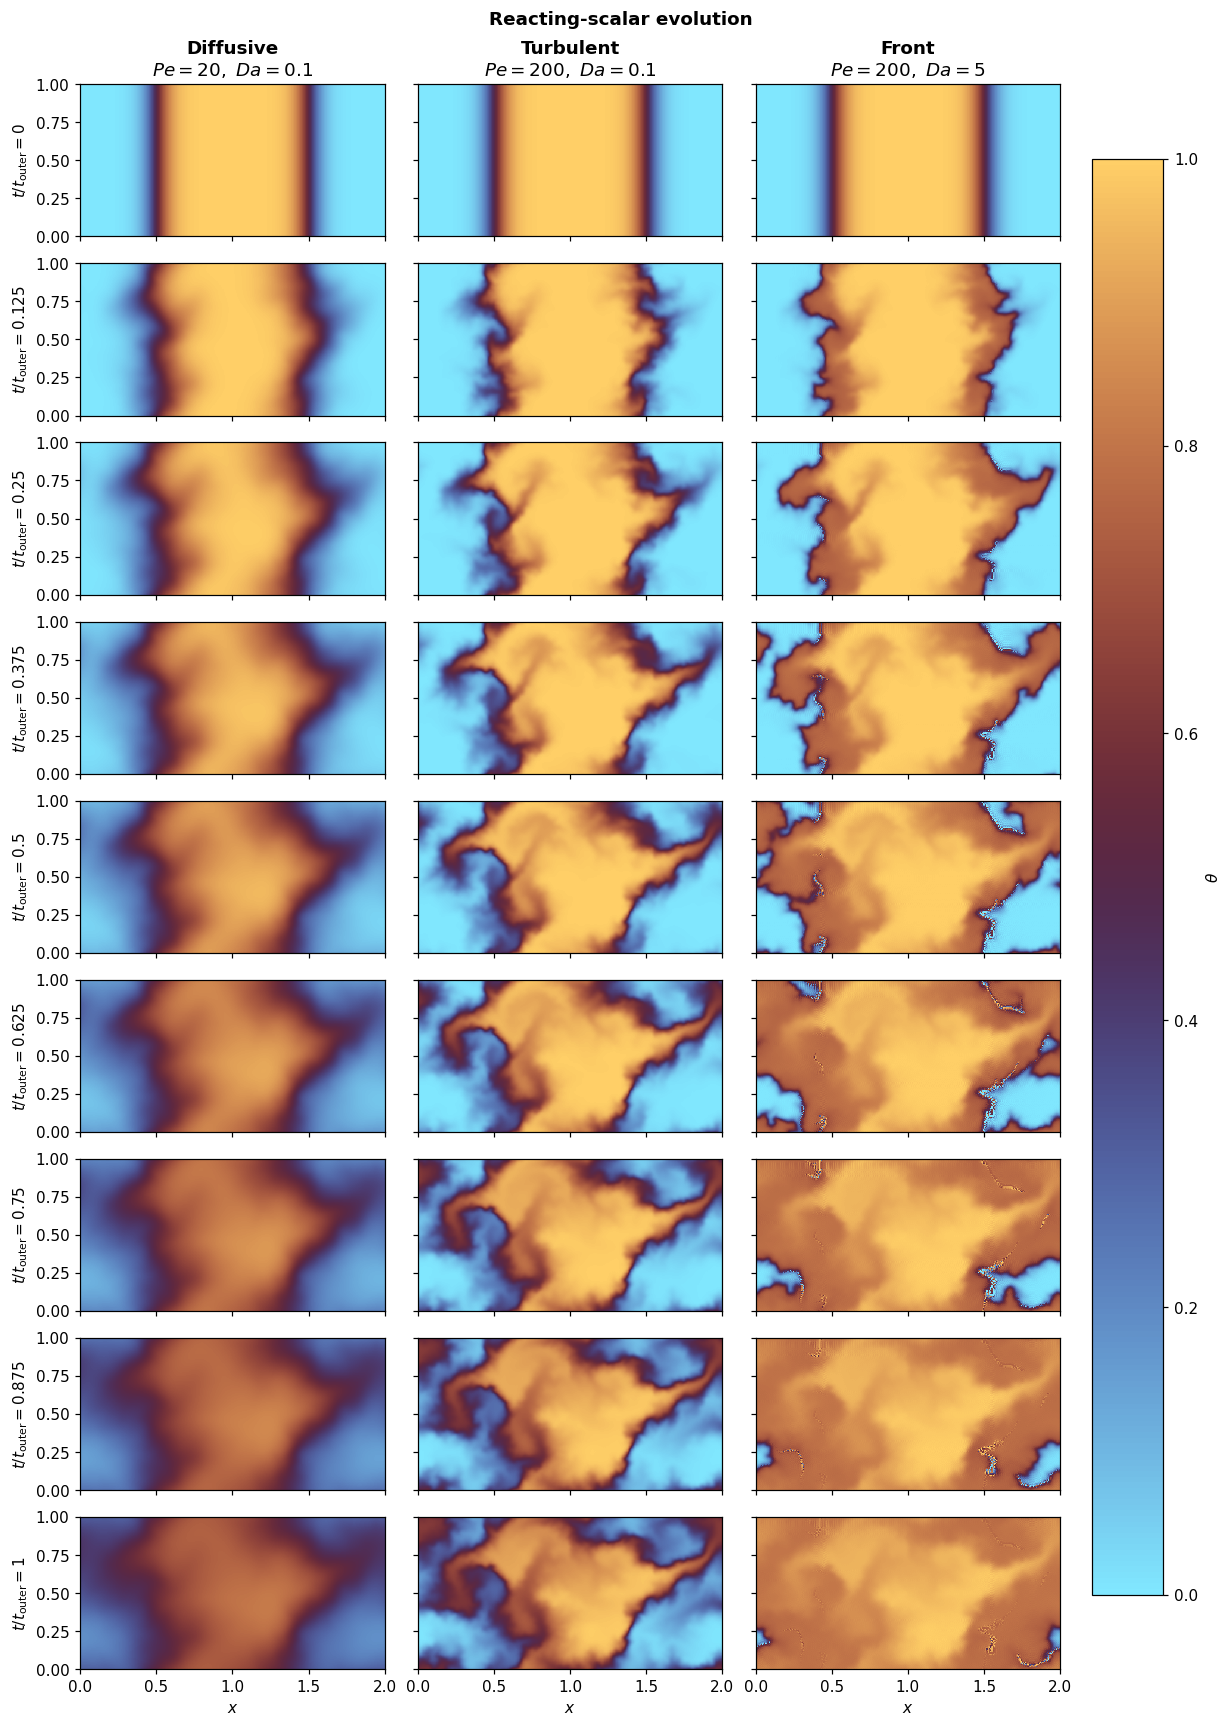

In [ ]:
# Rows show time; columns compare the three physical regimes.
# Scale the figure height automatically with the number of snapshot rows.
figure_height = 1.65 * len(save_times) + 0.75
fig, axes = plt.subplots(
    len(save_times),
    len(Pe_list),
    figsize=(11, figure_height),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

for col_idx, (Pe, Da, name, snap) in enumerate(
    zip(Pe_list, Da_list, regime_names, all_results)
):
    for row_idx, (time_over_t_outer, time) in enumerate(
        zip(save_times_over_t_outer, save_times)
    ):
        ax = axes[row_idx, col_idx]
        image = ax.imshow(
            snap[time],
            extent=(0, Lx, 0, Ly),
            origin="lower",
            cmap="managua_r",
            vmin=0,
            vmax=1,
            interpolation="nearest",
        )

        # Label each simulation once, across the top.
        if row_idx == 0:
            ax.set_title(
                f"{name}\n"
                rf"$Pe={Pe:g},\ Da={Da:g}$",
                fontweight="bold",
            )

        # Label each snapshot once, down the left side.
        if col_idx == 0:
            ax.set_ylabel(
                rf"$t/t_{{\rm outer}}={time_over_t_outer:g}$"
            )


        if row_idx == len(save_times) - 1:
            ax.set_xlabel("$x$")

# Every panel uses the same scalar range, so one colorbar serves the full figure.
fig.colorbar(
    image,
    ax=axes,
    label=r"$\theta$",
    location="right",
    shrink=0.9,
    pad=0.02,
)
fig.suptitle("Reacting-scalar evolution", fontweight="bold")
plt.show()

## Velocity Normalization

Our synthetic turbulent velocity field is generated in Fourier space using random Gaussian noise filtered by a Kolmogorov cascade ($E(k) \propto k^{-5/3}$). When transforming this field back to physical space, the standard IFFT algorithm scales the amplitude down by a factor of the total grid size ($N_x \times N_y$), resulting in an arbitrarily tiny raw velocity. To make the physics meaningful, we normalize the field by dividing it by its root-mean-square magnitude:

$$\mathbf{u}_{\text{norm}} = \frac{\mathbf{u}}{\sqrt{\langle |\mathbf{u}|^2 \rangle}}$$

This forces $U_{\text{rms}} = 1.0$. This scaling preserves the divergence-free condition ($\nabla \cdot \mathbf{u} = 0$) and the $k^{-5/3}$ turbulent energy distribution. Together with the user-specified $L_{\rm outer}$, it anchors $Pe$, $Da$, and the outer-scale turnover time $t_{\rm outer}=L_{\rm outer}/U_{\rm rms}$.

## 2/3 De-aliasing Rule

Because we evaluate the nonlinear multiplication $\mathbf{u} \cdot \nabla \theta$ in physical space, we encounter spectral aliasing. We multiply two signals, and so their frequencies add together. If two high-frequency waves interact, their product can exceed the maximum frequency the grid can resolve. The math library misinterprets these unresolvable high frequencies as low-frequency waves, causing artificial energy to potentially crash the solver.

We can apply orszag's 2/3 rule to prevent this:

$$\hat{\theta}(k_x, k_y) = 0 \quad \text{for} \quad |k| > \frac{2}{3}k_{\max}$$

By zeroing out the top 1/3 of the wavenumber spectrum at the beginning of every sub-step, the maximum frequency generated by nonlinear multiplication is capped at $\frac{4}{3} k_{\max}$. While this excess energy does alias, it lands in the upper-third region that we erase on the next step. We only sacrifice a small amount of spatial resolution to guarantee mathematical stability.